# 第050讲 数据划分与评价对象

先定义谁与何时，再看分数。60设备×48天、两天标签延迟、四份固定协议和三种简单模型。第0份作实例，另80份独立重抽；不选好seed、不删除负面结果。按顺序从新内核执行。

In [1]:
from pathlib import Path
import hashlib, json, os, sys
ROOT=Path.cwd().resolve()
EXPECTED={'experiment.py': 'eef7f25afda358799c20b284bb0b490e80c47a7819f670c2d3fef66b26f969d1', 'audit.py': 'fc7e8807ec943852bd6e14c158874d582acf2ddca1bc106435d94e27a38d1450', 'plots.py': '2a7f98e324f8e86a17255a7762eca81ca8109427c384402a8062477767c0da2a', 'data_integrity.json': 'bf679435483986b66340cdf027f79808822a5d338e2cfc402eafba745ccd0460', 'data/protocol.json': '137325bcfb7365ad550706084af9b30866665a236e8beb9e6e0a21aa661dcb0e', 'data/draws.npz': '844aff958276f0f26949cfddab8e64b007c0afaf8c57c1043d3ef2e919657e71', 'data/splits.npz': 'f6e32ea1b69e246b4306da9b8caa932ea3da10e92387a6c5099806c32eafd7eb', 'data/panel.csv': '647faabfa26b7e6f1f132e5a389914d1caf980f1da05b547a72aab8e5e9d0845', 'data/split_membership.csv': 'def800c0a10674b33ca394bf10fe97d4cf319d884f9a6575162ad099431591f6', 'data/hand.csv': '7a8051fd56ad96b26d2b80427f7fb796a610d44f41f4645dcff49c26b5db102a'}
for name, expected in EXPECTED.items():
    path=ROOT/name
    if not path.is_file() or hashlib.sha256(path.read_bytes()).hexdigest()!=expected:
        raise RuntimeError("Missing or modified teaching input: "+name)
print("Verified",len(EXPECTED),"source and data files")

Verified 10 source and data files


## 1 环境和固定协议

模型只读训练数据。模拟器a、μ仅用于解释，测试标签不用于选择。随机与整组在观察期结束后回顾拟合，时间与联合在32日截止。

In [2]:
import numpy as np
import scipy, sklearn, matplotlib, ipykernel
import experiment as e
import audit, plots
from IPython.display import display, Image
print({"python":sys.version.split()[0],"numpy":np.__version__,"scipy":scipy.__version__,"sklearn":sklearn.__version__,"matplotlib":matplotlib.__version__,"ipykernel":ipykernel.__version__})
c,draws,splits=e.load_data()
p=e.panel(c,draws,0)
print(json.dumps(c,ensure_ascii=False,indent=2))

{'python': '3.12.14', 'numpy': '2.3.5', 'scipy': '1.17.0', 'sklearn': '1.8.0', 'matplotlib': '3.10.8', 'ipykernel': '7.4.0'}
{
  "protocol_version": "050-v1-pre-result",
  "data_seed": 50017,
  "split_seed": 50053,
  "bootstrap_seed": 50059,
  "independent_repetitions": 80,
  "n_devices": 60,
  "n_days": 48,
  "label_delay_days": 2,
  "fit_cutoff_day": 32,
  "future_first_day": 33,
  "test_fraction": 0.25,
  "intercept": 2.0,
  "signal_slope": 1.4,
  "device_sd": 1.2,
  "response_drift_per_day": 0.045,
  "x_drift_per_day": 0.015,
  "noise_sd": 0.5,
  "ridge_alpha": 1.0,
  "models": [
    "pooled",
    "personalized",
    "trend"
  ],
  "splits": [
    "random",
    "group",
    "time",
    "group_time"
  ],
  "bootstrap_repetitions": 800,
  "interpretation": "Replicate 0 is the worked table; replicates 1..80 are independent new synthetic panels. Split indices, models, alpha and all constants fixed before observing scores. Each split targets a different evaluation population. No tuning,

## 2 四行逐样本链

θ顺序b,w,vA,vB。先做前向、残差、半平方损失，再聚合局部导数，η=0.2同步更新。H5、H6测试行不得进梯度。

In [3]:
h=e.hand()
for row in h["rows"]:
    print(row)
print("Mean gradient",h["gradient_mean"])
print("Synchronized update",h["theta_next"])
print("J next",h["next_objective"],"test-only next predictions",h["test_next_predictions"])
print("Independent fractions:",audit.exact_hand())

{'row': 'H1', 'features': [1.0, 0.0, 1.0, 0.0], 'y': 1.0, 'prediction': 0.0, 'residual': -1.0, 'half_squared_loss': 0.5, 'local_derivatives': [-1.0, -0.0, -1.0, -0.0], 'next_prediction': 0.7, 'next_half_squared_loss': 0.04500000000000001}
{'row': 'H2', 'features': [1.0, 1.0, 1.0, 0.0], 'y': 3.0, 'prediction': 0.0, 'residual': -3.0, 'half_squared_loss': 4.5, 'local_derivatives': [-3.0, -3.0, -3.0, -0.0], 'next_prediction': 1.05, 'next_half_squared_loss': 1.9012499999999999}
{'row': 'H3', 'features': [1.0, 0.0, 0.0, 1.0], 'y': 2.0, 'prediction': 0.0, 'residual': -2.0, 'half_squared_loss': 2.0, 'local_derivatives': [-2.0, -0.0, -0.0, -2.0], 'next_prediction': 0.8, 'next_half_squared_loss': 0.72}
{'row': 'H4', 'features': [1.0, 1.0, 0.0, 1.0], 'y': 4.0, 'prediction': 0.0, 'residual': -4.0, 'half_squared_loss': 8.0, 'local_derivatives': [-4.0, -4.0, -0.0, -4.0], 'next_prediction': 1.1500000000000001, 'next_half_squared_loss': 4.061249999999999}
Mean gradient [-2.5, -1.75, -1.0, -1.5]
Synchr

## 3 验证分组与时间边界

训练必须在实际拟合截止时拿到标签，不能仅比较事件日期。联合任务主动不用新设备早期数据，模拟冷启动。

In [4]:
for kind,(tr,te) in splits.items():
    e.validate_split(p,tr,te,kind,c["fit_cutoff_day"])
    print(kind,{"train":len(tr),"test":len(te),"unused":len(p["x"])-len(tr)-len(te),"overlap_groups":len(np.intersect1d(p["group"][tr],p["group"][te])),"last_label_available":int(p["available"][tr].max()),"first_test_day":int(p["day"][te].min())})

random {'train': 2160, 'test': 720, 'unused': 0, 'overlap_groups': 60, 'last_label_available': 49, 'first_test_day': 0}
group {'train': 2160, 'test': 720, 'unused': 0, 'overlap_groups': 0, 'last_label_available': 49, 'first_test_day': 0}
time {'train': 1860, 'test': 900, 'unused': 120, 'overlap_groups': 60, 'last_label_available': 32, 'first_test_day': 33}
group_time {'train': 1395, 'test': 225, 'unused': 1260, 'overlap_groups': 0, 'last_label_available': 32, 'first_test_day': 33}


## 4 完整主实验与重复

主例12次拟合，独立80面板再拟合960次。模型使用增广最小二乘，不用手算的一步GD作为最终拟合。

In [5]:
result=e.run()
e.atomic_json(ROOT/"outputs/notebook-result.json",result)
for kind in e.SPLITS:
    print(kind,{m:result["main"][kind]["models"][m]["mse"] for m in e.MODELS})
print("Retained repeated fits",len(result["replications"])*12)
print("All negative comparisons",result["negative_results"])

random {'pooled': 1.7512869996843865, 'personalized': 0.63679531171046, 'trend': 0.24327106243557978}
group {'pooled': 1.8521821863792485, 'personalized': 1.8475849970822134, 'trend': 1.450288418293592}
time {'pooled': 2.6865976419663755, 'personalized': 1.4963203220358476, 'trend': 0.2371875200405628}
group_time {'pooled': 2.9209420786611737, 'personalized': 2.9387578590839754, 'trend': 1.4616573462202365}
Retained repeated fits 960
All negative comparisons {'random': {'personalized_worse_than_pooled': 0, 'trend_worse_than_personalized': 0}, 'group': {'personalized_worse_than_pooled': 34, 'trend_worse_than_personalized': 0}, 'time': {'personalized_worse_than_pooled': 0, 'trend_worse_than_personalized': 0}, 'group_time': {'personalized_worse_than_pooled': 38, 'trend_worse_than_personalized': 3}}


## 5 真实独立科学参照

独立OneHotEncoder只fit训练类别，Ridge SVD与SciPy QR核验全部12个主例。测试标签变更、常见输入及输出保全也实际测试。

In [6]:
checks=audit.run(result)
e.atomic_json(ROOT/"outputs/notebook-audit.json",checks)
print(json.dumps(checks,ensure_ascii=False,indent=2))

{
  "status": "passed",
  "independent_reference_fits": [
    {
      "split": "random",
      "model": "pooled",
      "sklearn_max_prediction_error": 5.329070518200751e-15,
      "scipy_QR_max_prediction_error": 3.552713678800501e-15
    },
    {
      "split": "random",
      "model": "personalized",
      "sklearn_max_prediction_error": 1.2434497875801753e-14,
      "scipy_QR_max_prediction_error": 1.199040866595169e-14
    },
    {
      "split": "random",
      "model": "trend",
      "sklearn_max_prediction_error": 6.750155989720952e-14,
      "scipy_QR_max_prediction_error": 1.4210854715202004e-14
    },
    {
      "split": "group",
      "model": "pooled",
      "sklearn_max_prediction_error": 7.105427357601002e-15,
      "scipy_QR_max_prediction_error": 3.552713678800501e-15
    },
    {
      "split": "group",
      "model": "personalized",
      "sklearn_max_prediction_error": 7.105427357601002e-15,
      "scipy_QR_max_prediction_error": 6.217248937900877e-15
    },
    {


## 6 把未知设备编码看见

以下不复用课程设计函数。整组测试设备未见，指示列全为0。相同数值alpha只有在目标尺度匹配时才能对照。

In [7]:
from sklearn.preprocessing import OneHotEncoder
from sklearn.linear_model import Ridge
tr,te=splits["group"]
enc=OneHotEncoder(handle_unknown="ignore",sparse_output=False)
gtr=enc.fit_transform(p["group"][tr,None]);gte=enc.transform(p["group"][te,None])
X=np.column_stack([p["x"][tr],gtr]);Xt=np.column_stack([p["x"][te],gte])
model=Ridge(alpha=1,fit_intercept=True,solver="svd").fit(X,p["y"][tr])
print("Unknown group feature sum",float(gte.sum()))
print("Actual sklearn MSE",float(np.mean((model.predict(Xt)-p["y"][te])**2)))

Unknown group feature sum 0.0
Actual sklearn MSE 1.8475849970822134


## 7 期望噪声与有限测试

MSE已经与含噪y比较，不再加噪声。oracle_conditional_mse在当前固定测试设计下只对新的标签噪声取期望，不是所有未来的总体风险。

In [8]:
for kind in e.SPLITS:
    q=result["main"][kind]["models"]["trend"]
    print(kind,{"finite_test_MSE":q["mse"],"oracle_noise_average":q["oracle_conditional_mse"],"noise_variance":c["noise_sd"]**2})
for kind in e.SPLITS:
    print(kind,result["summary"][kind]["personalized"])

random {'finite_test_MSE': 0.24327106243557978, 'oracle_noise_average': 0.2568503816693709, 'noise_variance': 0.25}
group {'finite_test_MSE': 1.450288418293592, 'oracle_noise_average': 1.4795312488479975, 'noise_variance': 0.25}
time {'finite_test_MSE': 0.2371875200405628, 'oracle_noise_average': 0.2589668428166186, 'noise_variance': 0.25}
group_time {'finite_test_MSE': 1.4616573462202365, 'oracle_noise_average': 1.4758859603459662, 'noise_variance': 0.25}
random {'mean_mse': 0.6364056674598382, 'sd_between_panels': 0.029069589481733292, 'mcse_mean': 0.003250078907958426, 'q10': 0.6005030653586313, 'q90': 0.6702882979543803, 'min': 0.5495824184411733, 'max': 0.7049673791780623}
group {'mean_mse': 2.140159908358754, 'sd_between_panels': 0.5545105843102482, 'mcse_mean': 0.06199616803804217, 'q10': 1.4013818289893787, 'q90': 2.741877494672543, 'min': 1.1552729631593657, 'max': 4.739463827871571}
time {'mean_mse': 1.5141189703075084, 'sd_between_panels': 0.05158402707207543, 'mcse_mean': 0

## 8 权重与Bootstrap单位

720行来自15个独立留出设备。固定模型不重训，只重采样测试；800次百分位区间未做覆盖率验证。

In [9]:
print(result["weight_example"])
b=result["bootstrap"]
print({k:v for k,v in b.items() if "draws" not in k})
print("Random split row / device mean",{k:result["main"]["random"]["models"]["personalized"][k] for k in ["mse","group_mean_mse"]})

{'group_sizes': [8, 2], 'model_A_group_losses': [1, 9], 'model_B_group_losses': [4, 4], 'A_row_mse': 2.6, 'B_row_mse': 4.0, 'A_group_mse': 5.0, 'B_group_mse': 4.0}
{'estimand': 'conditional on fitted model; equal-device empirical test risk; no refit, calendar fixed', 'row_sd': 0.09779021286367864, 'group_sd': 0.42364744479787364, 'row_percentile_95': [1.6661939503040162, 2.0426071586982166], 'group_percentile_95': [1.085890680851555, 2.720593621956896], 'independent_groups': 15, 'rows': 720}
Random split row / device mean {'mse': 0.63679531171046, 'group_mean_mse': 0.6311418920905337}


## 9 时间API的单位

对48个日索引设置gap=2才表示两天，再映射为面板行。以下仅演示接口，不改变主实验四个协议、不作调参。

In [10]:
from sklearn.model_selection import TimeSeriesSplit
for trd,ted in TimeSeriesSplit(n_splits=3,test_size=8,gap=2).split(np.arange(48)):
    tr=np.flatnonzero(np.isin(p["day"],trd));te=np.flatnonzero(np.isin(p["day"],ted))
    print({"last_train_day":int(trd[-1]),"first_test_day":int(ted[0]),"last_test_day":int(ted[-1]),"train_rows":len(tr),"test_rows":len(te)})

{'last_train_day': 21, 'first_test_day': 24, 'last_test_day': 31, 'train_rows': 1320, 'test_rows': 480}
{'last_train_day': 29, 'first_test_day': 32, 'last_test_day': 39, 'train_rows': 1800, 'test_rows': 480}
{'last_train_day': 37, 'first_test_day': 40, 'last_test_day': 47, 'train_rows': 2280, 'test_rows': 480}


## 10 重建并阅读全部十幅图

图5粗线为10%至90%范围，不是均值置信区间；图10为单独窗口例，区分历史重用的可实施性和统计独立性。

In [11]:
figure_dir=ROOT/"outputs/notebook-figures"
plots.render_all(result,figure_dir)
print("Generated figures:",len(plots.NAMES))

Generated figures: 10


01_split_maps


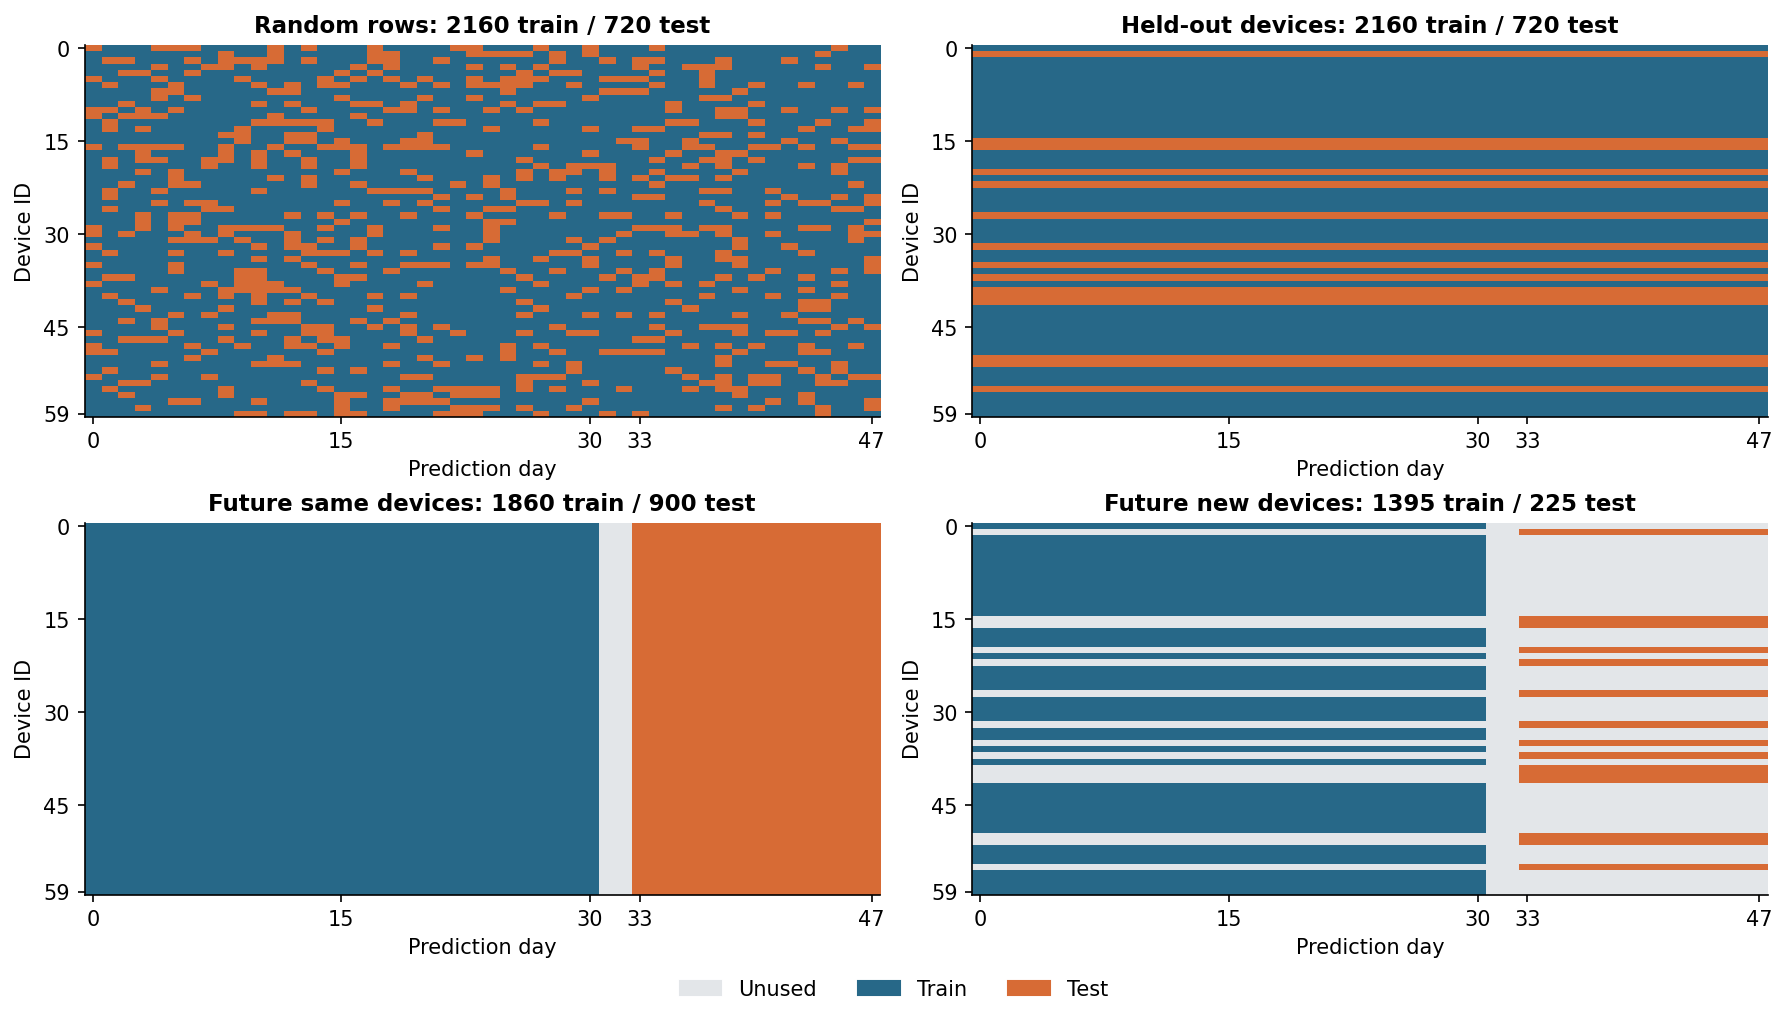

02_label_availability


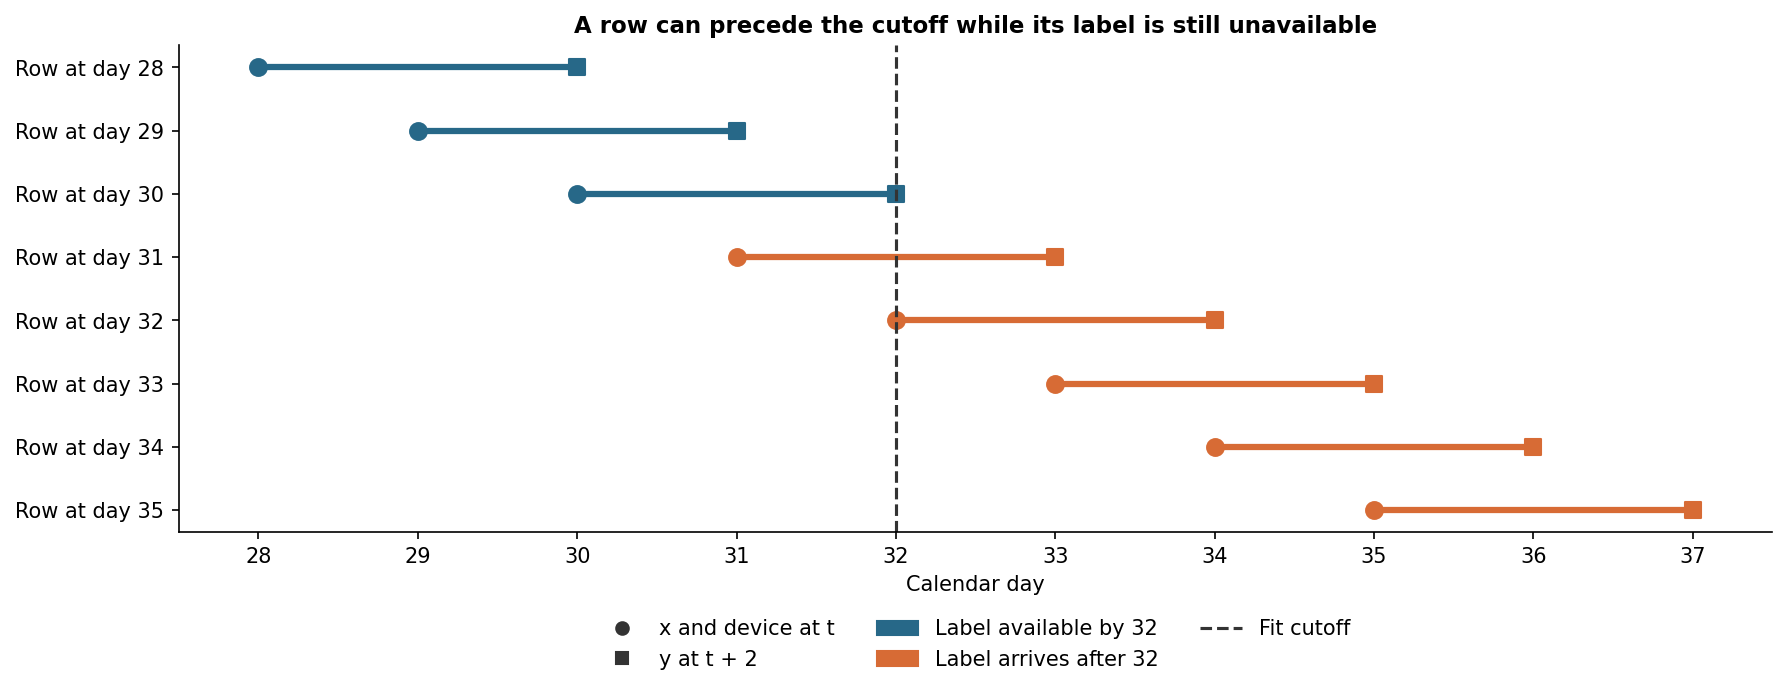

03_hand_step


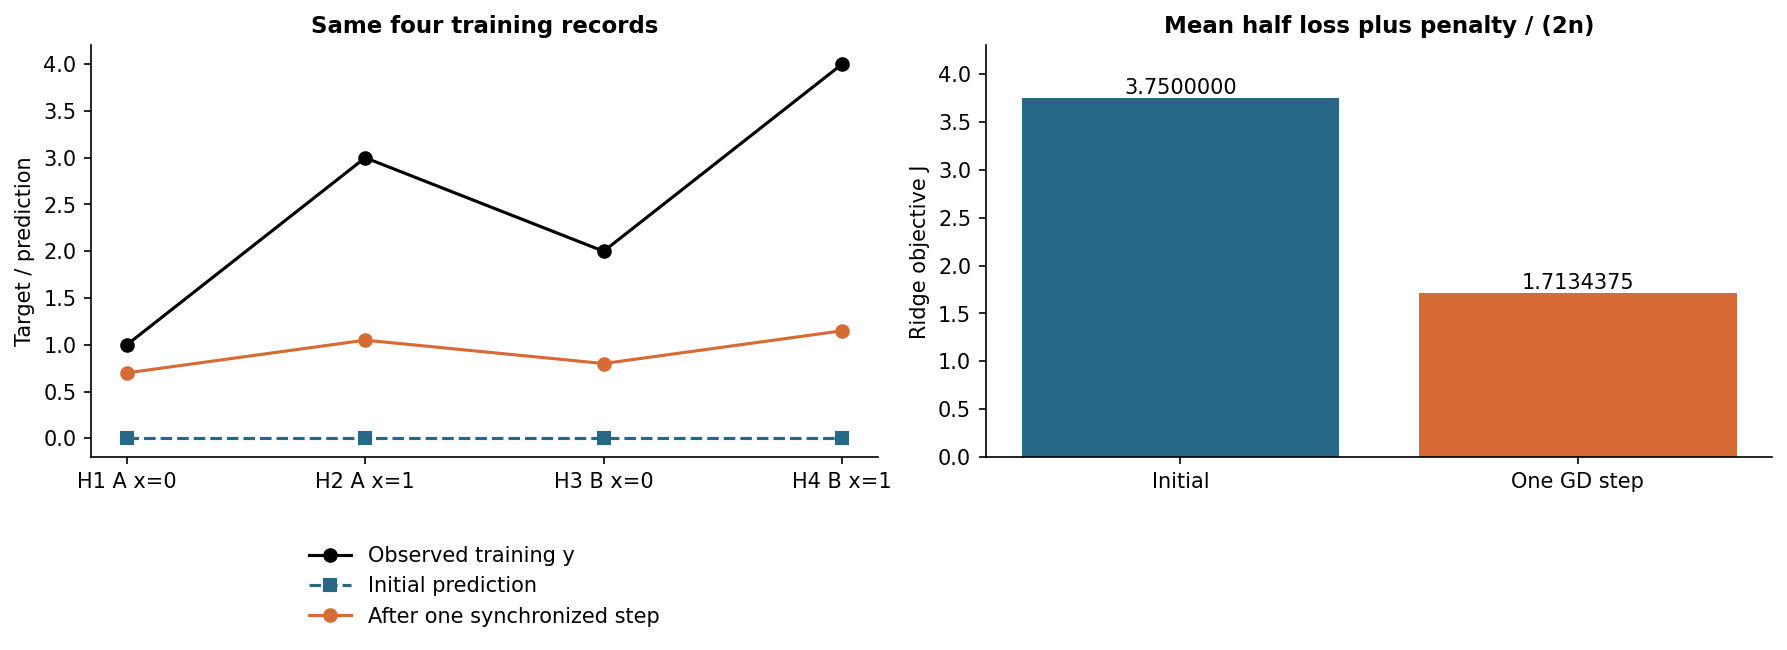

04_main_scores


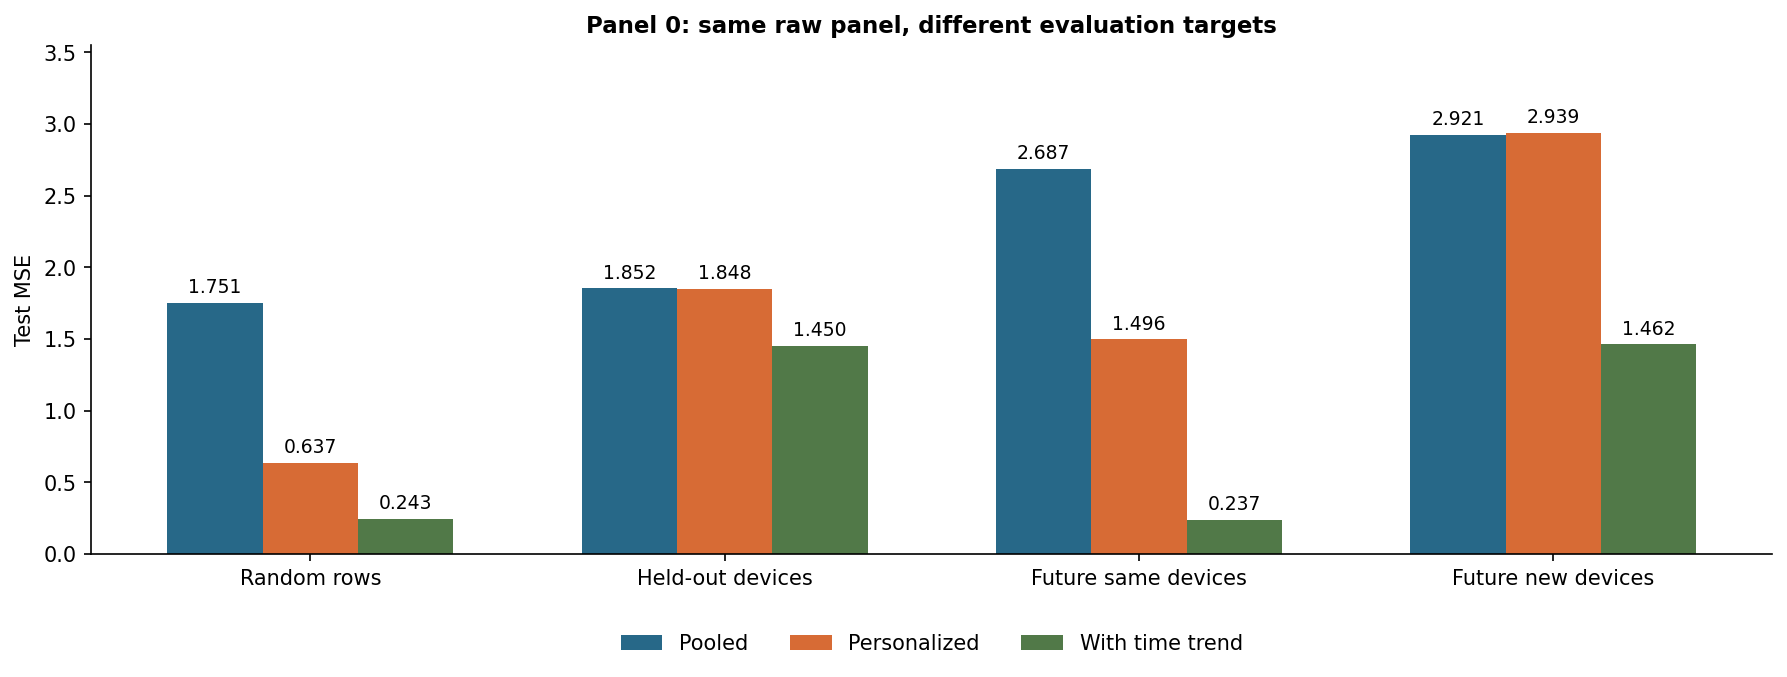

05_repeated_panels


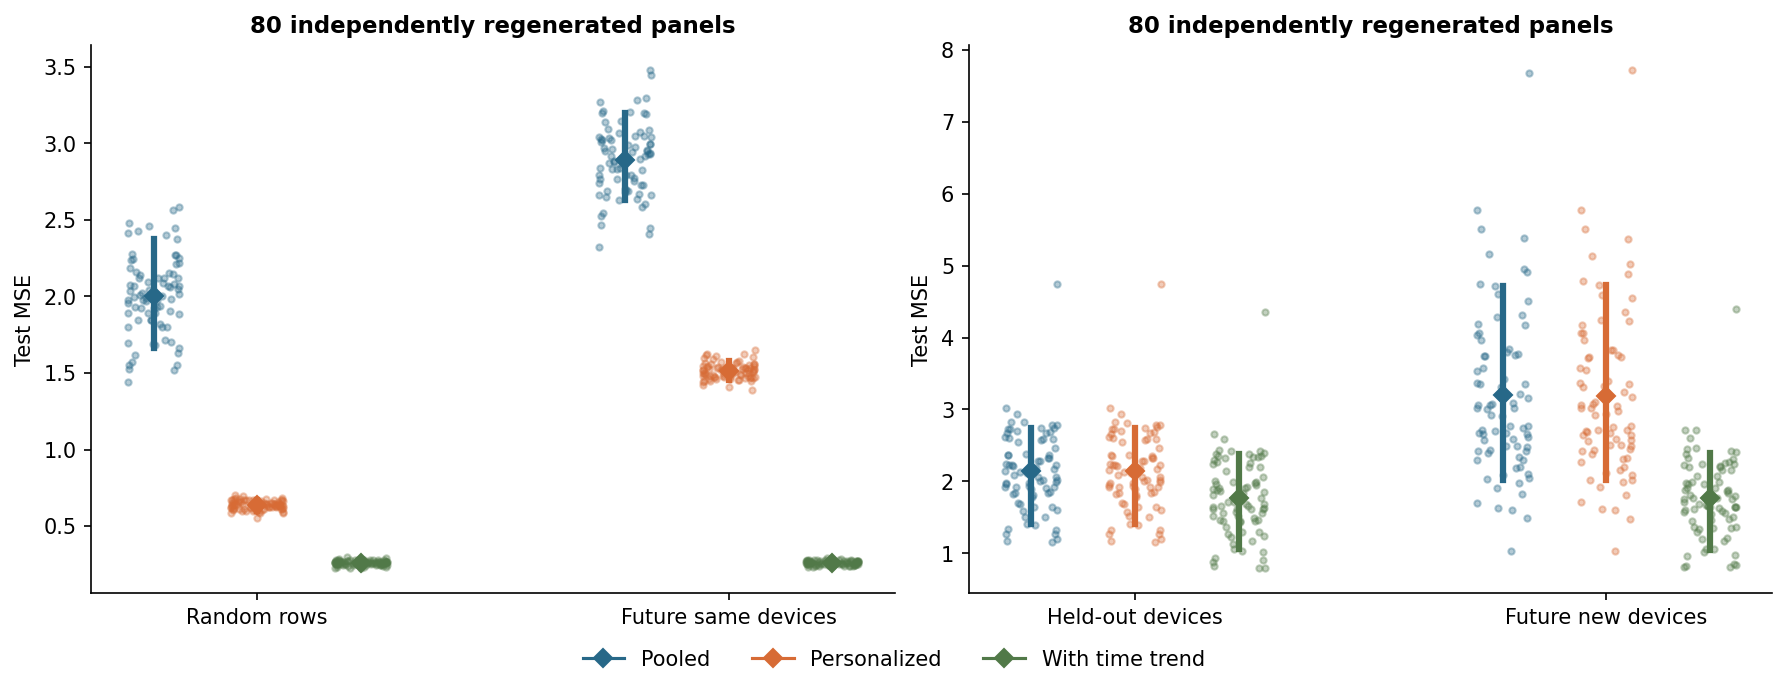

In [12]:
for name in plots.NAMES[:5]:
    print(name)
    display(Image(filename=str(figure_dir/(name+".png"))))

06_shift_and_residual


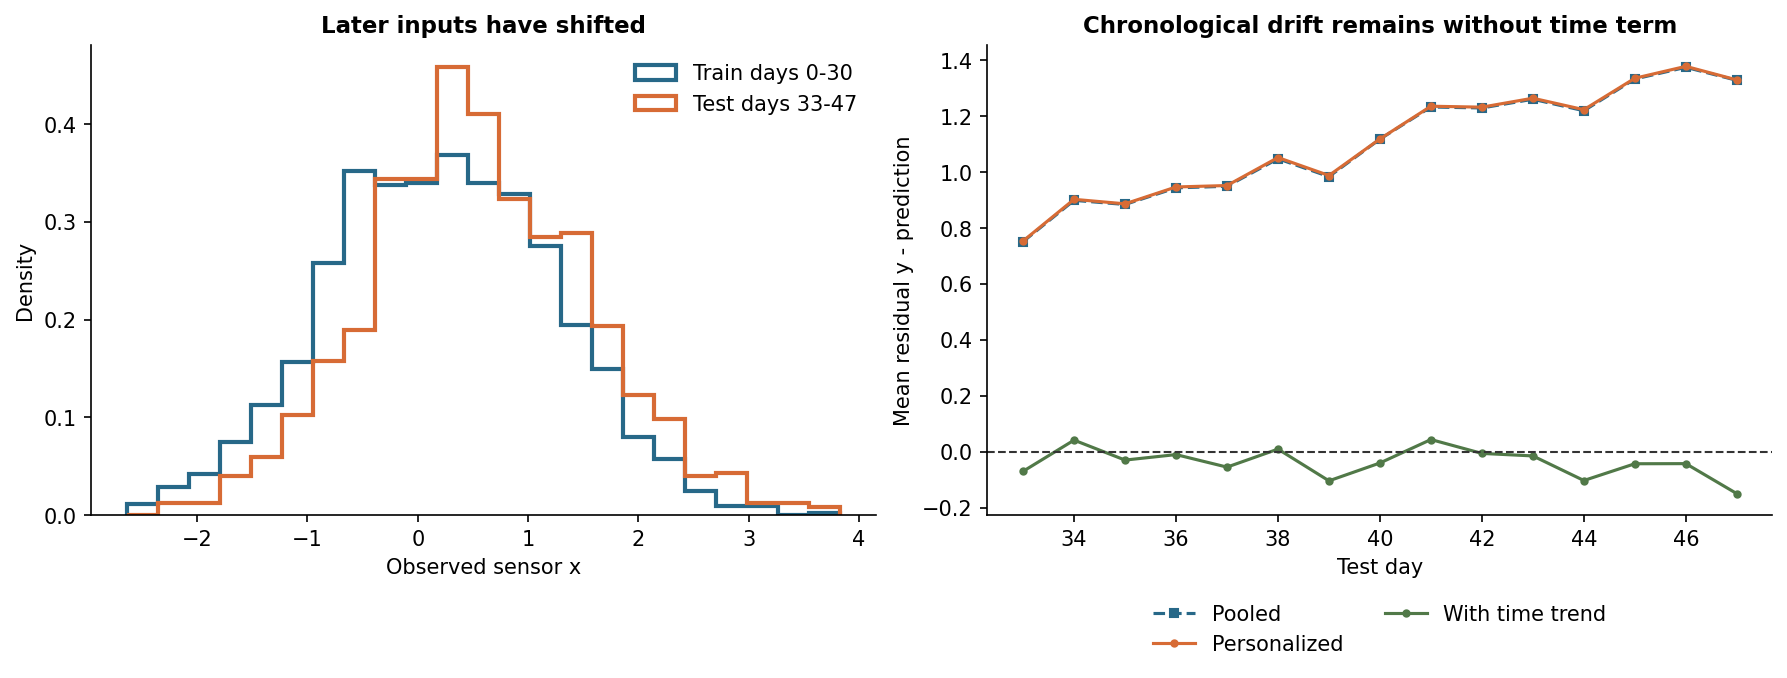

07_device_errors


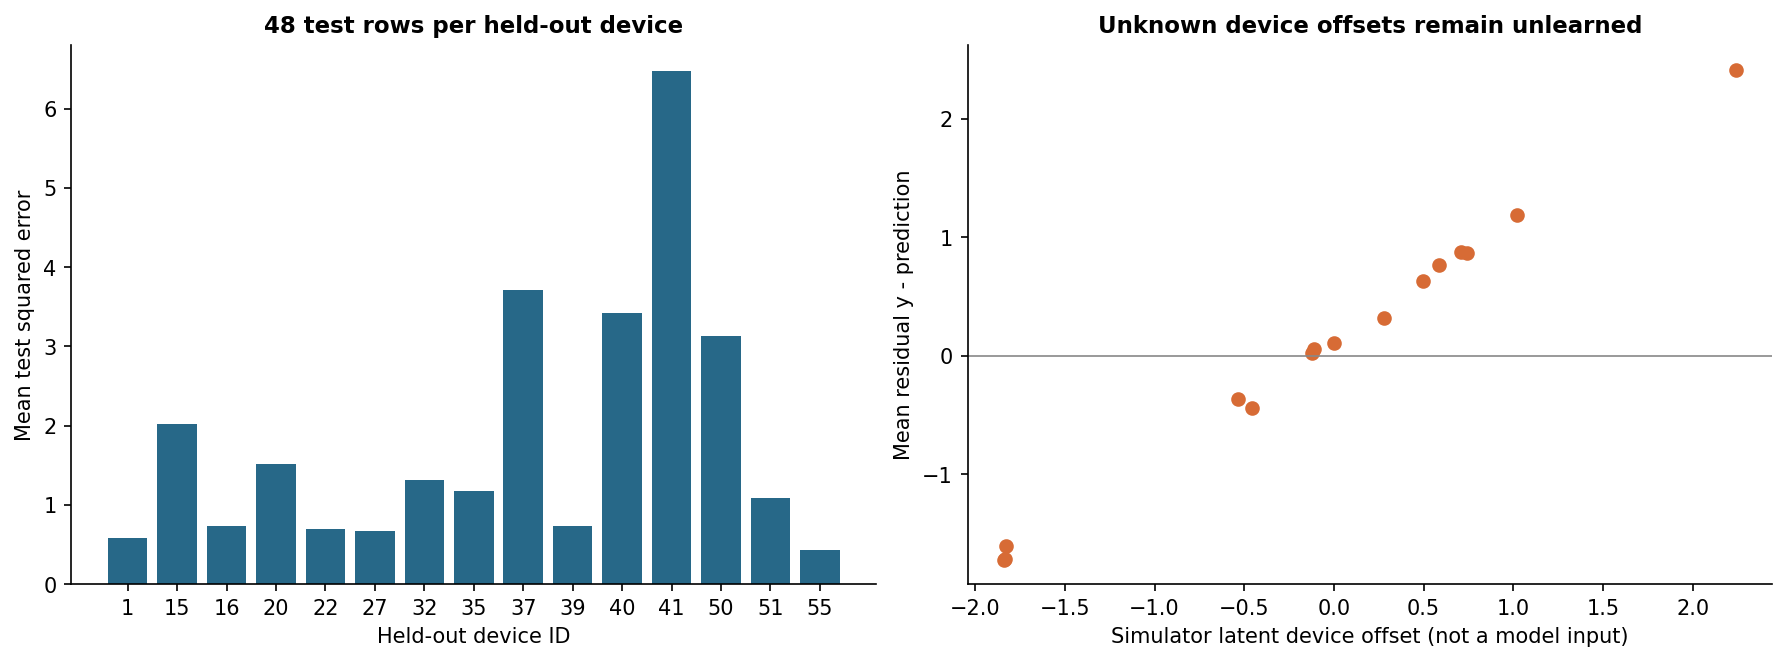

08_bootstrap_units


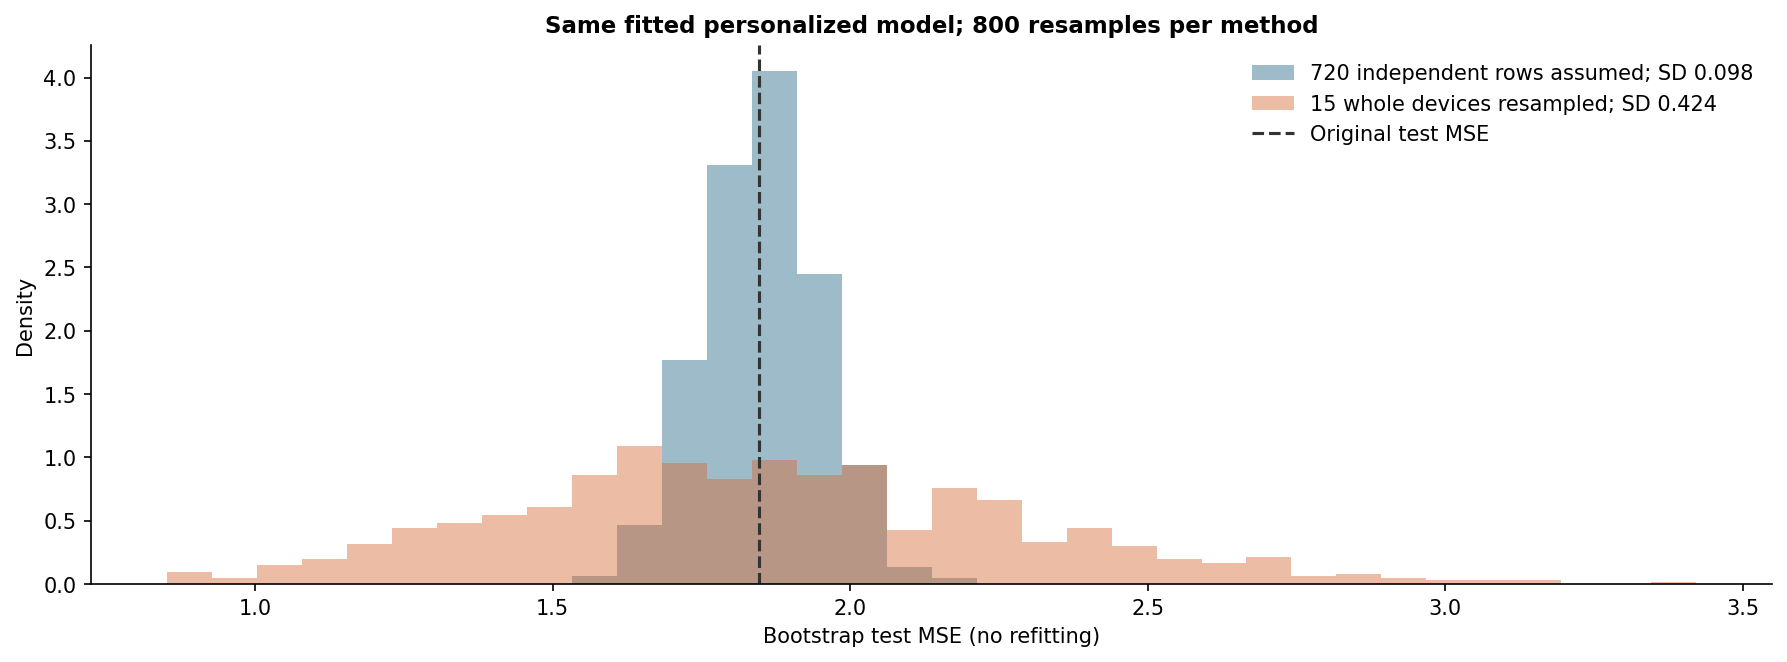

09_weighting_target


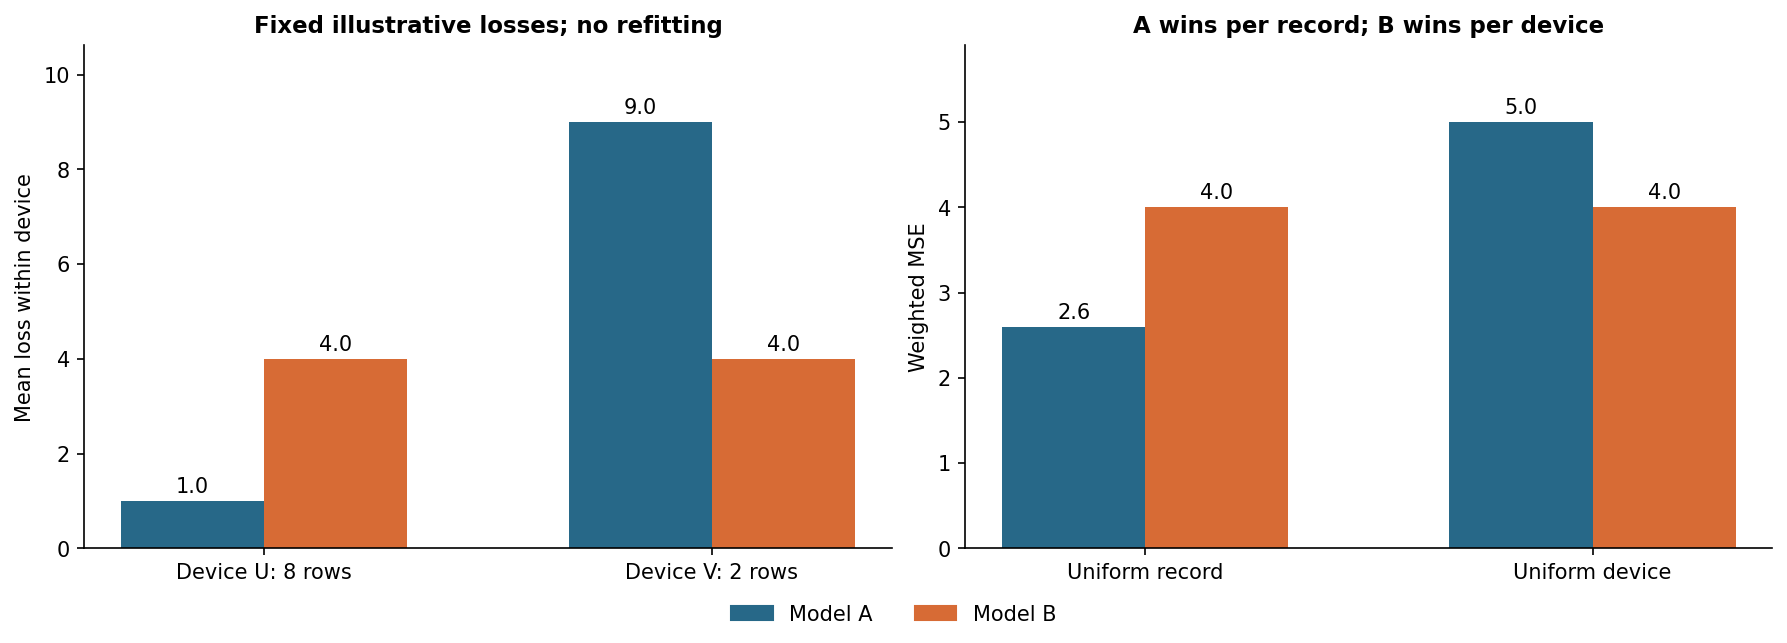

10_window_support


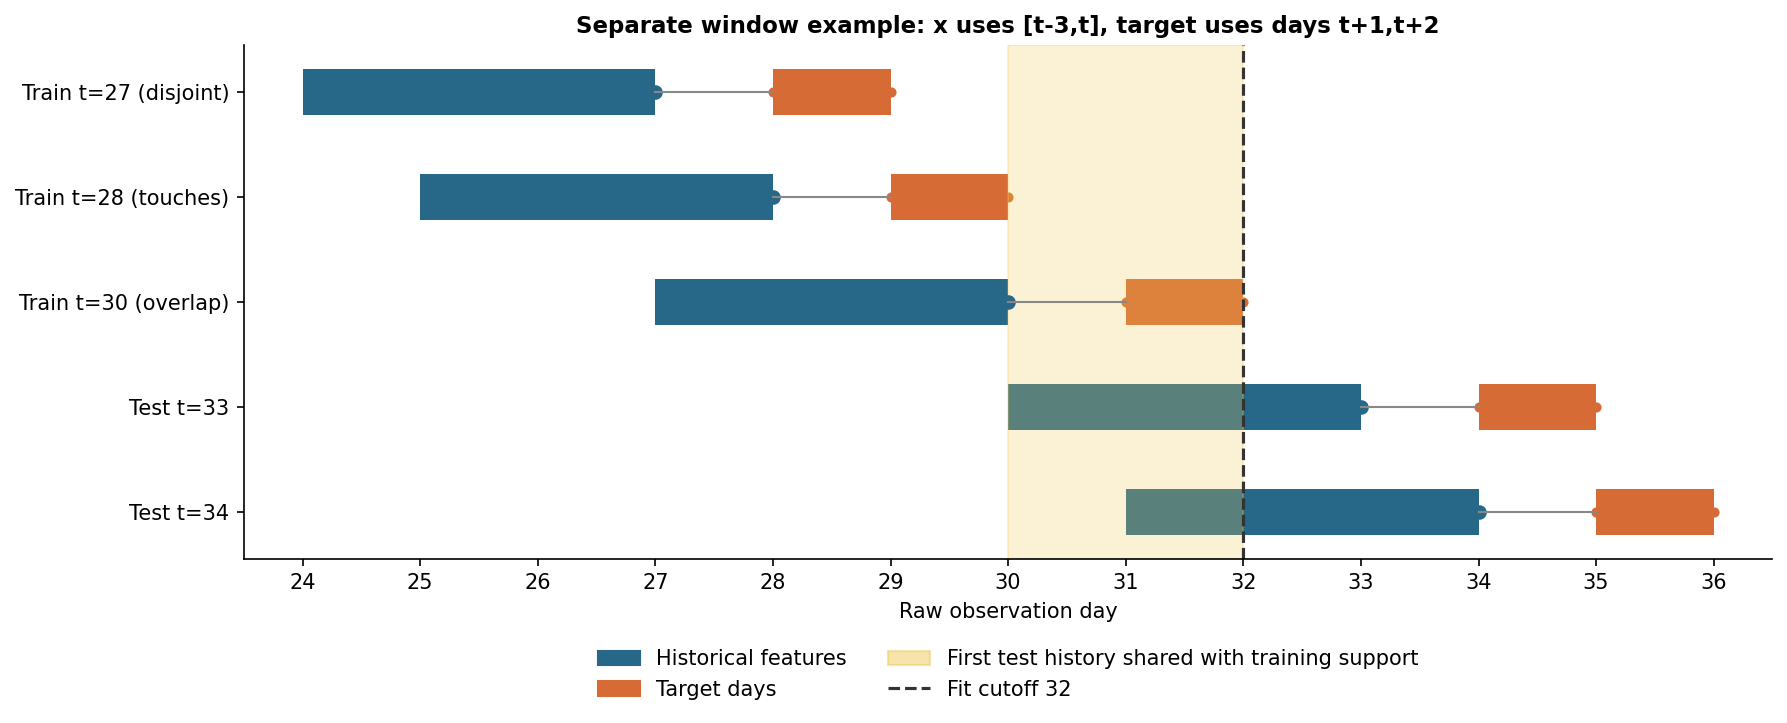

In [13]:
for name in plots.NAMES[5:]:
    print(name)
    display(Image(filename=str(figure_dir/(name+".png"))))

## 11 结束前写结论

1. 随机评分是回顾性已知设备插值，不能重命名为新设备未来。
2. 设备历史是否合法依赖部署目标与标签到达时刻。
3. Trend对线性漂移的优势有机制前提；联合80次中仍有3次更差。
4. 独立面板、测试设备Bootstrap、重复划分分别平均不同随机性。
5. 指标、权重、信息边界和失败处理应在看测试分数前确定。

完成讲义E1至E16、G1至G10和实验L1至L8，再对照答案。